<a href="https://colab.research.google.com/github/Paola-CC/ChallengeTelecomX-2/blob/main/Challenge_Telecom_X_an%C3%A1lisis_de_evasi%C3%B3n_de_clientes_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Challenge Telecom X: análisis de evasión de clientes - Parte 2**


---



##**1. Extracción del Archivo Tratado**

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [54]:
# Cargando el archivo
csv_file = '/content/datos_tratados.csv'
df = pd.read_csv(csv_file)
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 7267 filas y 34 columnas.


##**2. Eliminación de Columnas Irrelevantes**

In [55]:
#Quitamos el customerID y las columnas categóricas originales, ya que utilizaremos las versiones "binarias" que generamos en el proyecto anterior.
cols_to_drop = ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn']
df_model = df.drop(columns=cols_to_drop)

##**3. Encoding**

In [56]:
#Transformamos las variables como Contrato o Método de Pago en números usando get_dummies.
df_model = pd.get_dummies(df_model, columns=['InternetService', 'Contract', 'PaymentMethod', 'PaperlessBilling'], drop_first=True)

print("Columnas con strings restantes:", df_model.select_dtypes(include=['object']).columns.tolist())

Columnas con strings restantes: []


##**4. Verificación de la Proporción de Cancelación (Churn)**

Proporción de Clientes:
Churn_Binario
0    74.280996
1    25.719004
Name: proportion, dtype: float64


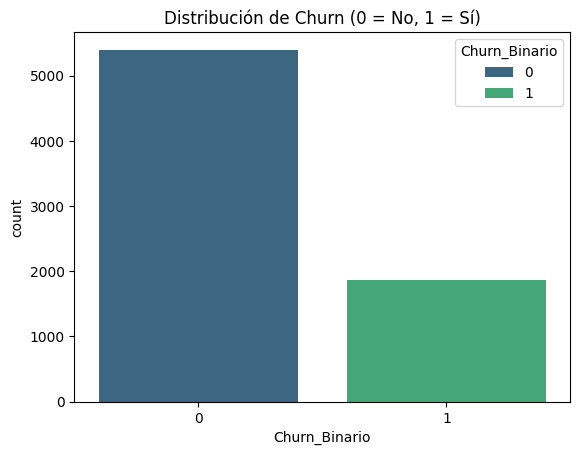

In [57]:
proporcion = df_model['Churn_Binario'].value_counts(normalize=True) * 100
print(f"Proporción de Clientes:\n{proporcion}")

sns.countplot(x='Churn_Binario',hue='Churn_Binario', data=df_model, palette='viridis')
plt.title('Distribución de Churn (0 = No, 1 = Sí)')
plt.show()

##**5. Balanceo de Clases**

In [58]:
# Usaremos SMOTE para que en caso de que exista un desbalance fuerte el modelo aprenda de mejor compra a identificar las cancelaciones

X = df_model.drop('Churn_Binario', axis=1)
y = df_model['Churn_Binario']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [59]:
print("Se complet[o el balanceo")
print(f"dimensiones: {X_resampled.shape}")

Se complet[o el balanceo
dimensiones: (10796, 24)


##**6. Normalización o Estandarización**

In [60]:
# Transformamos las variables a la misma escala para la regreci[on

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

##**7. Análisis de Correlación**

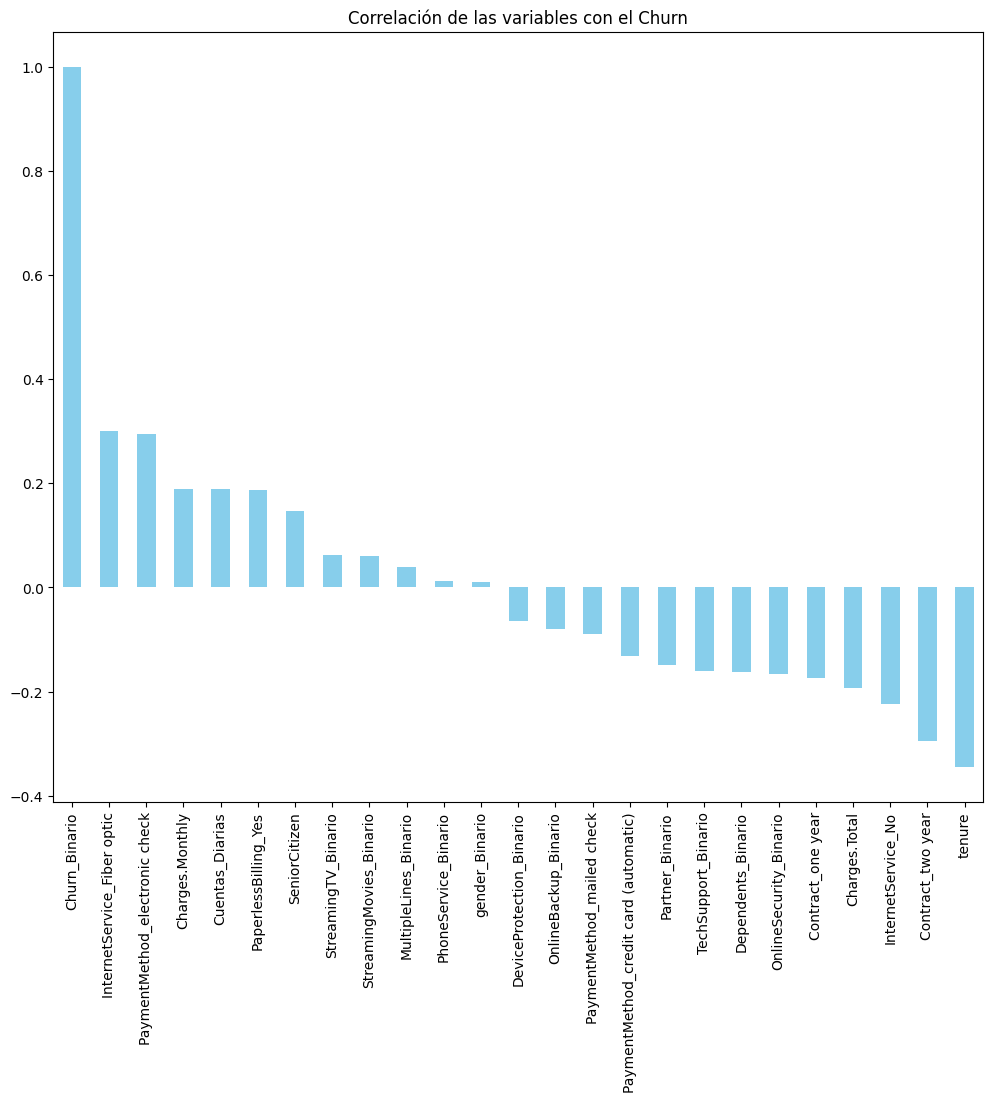

In [61]:
plt.figure(figsize=(12, 10))
correlacion = df_model.corr()['Churn_Binario'].sort_values(ascending=False)
correlacion.plot(kind='bar', color='skyblue')
plt.title("Correlación de las variables con el Churn")
plt.show()

##**8. Análisis Dirigido**

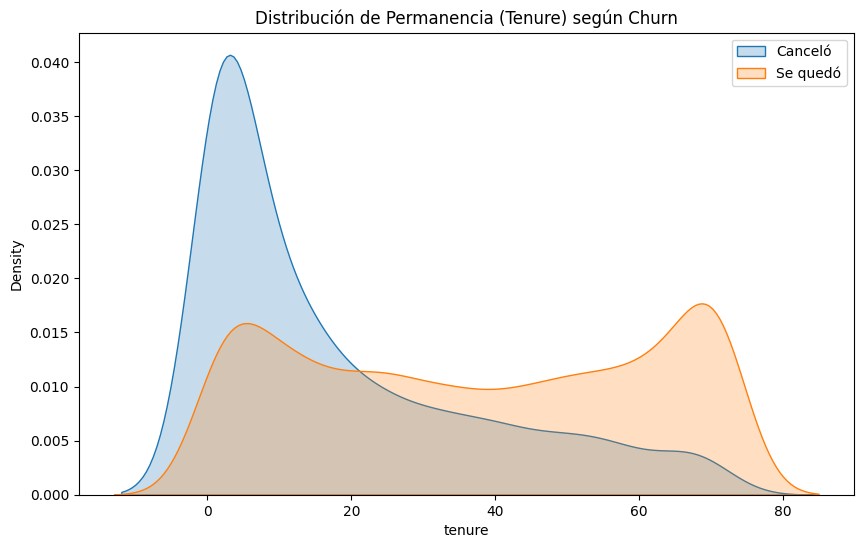

In [62]:
# Afectación de la cancelación por el tiempo de permanecia
plt.figure(figsize=(10,6))
sns.kdeplot(df_model[df_model['Churn_Binario'] == 1]['tenure'], label='Canceló', fill=True)
sns.kdeplot(df_model[df_model['Churn_Binario'] == 0]['tenure'], label='Se quedó', fill=True)
plt.title('Distribución de Permanencia (Tenure) según Churn')
plt.legend()
plt.show()

##**9. Separación de Datos**

In [63]:
#dividimos en 80% para entrenamiento,20% para prueba

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_train_sc, X_test_sc, _, _ = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42)


##**10. Creación de Modelos**

In [64]:
#Entrenamos una Regresión Logística y un Random Forest

#Modelo A Regresión Logística
model_lr = LogisticRegression()
model_lr.fit(X_train_sc, y_train)

#Modelo B: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)





RandomForestClassifier(random_state=42)

##**11. Evaluación de los Modelos y Métricas**

In [ ]:
#Vamos acomparar el rendimiento de ambos modelos con la matriz de confusión y métricas clave
def evaluar(nombre, modelo, X_v, y_v):
    preds = modelo.predict(X_v)
    print(f"\n--- {nombre} ---")
    print(classification_report(y_v, preds))
    sns.heatmap(confusion_matrix(y_v, preds), annot=True, fmt='g', cmap='Purples')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.show()

evaluar("Regresión Logística", model_lr, X_test_sc, y_test)
evaluar("Random Forest", model_rf, X_test, y_test)

##**13. Análisis de la Importancia de las Variables**

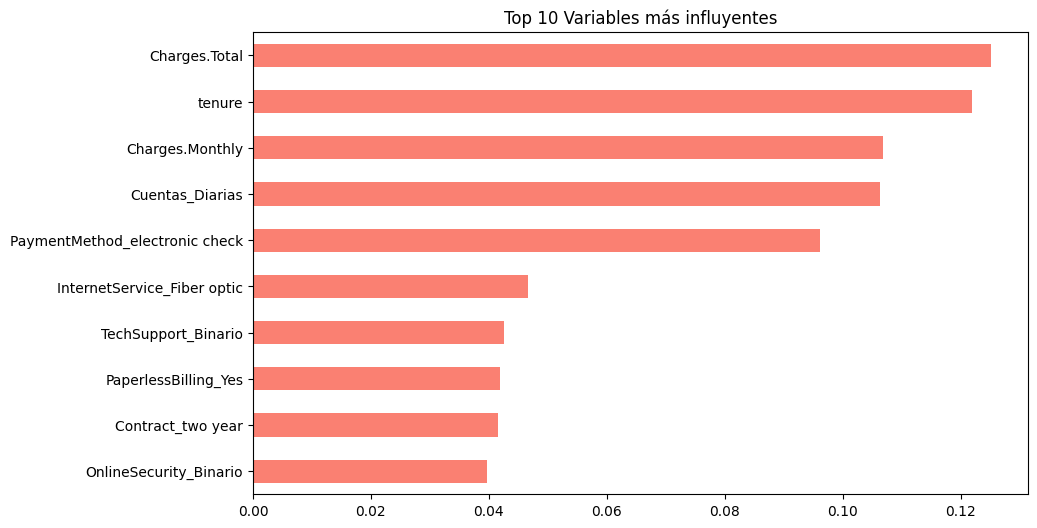

In [65]:
#Usando el Random Forest
importancia = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importancia.head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Variables más influyentes')
plt.gca().invert_yaxis()
plt.show()

##**13. Conclusión**



El análisis de datos revela que la pérdida de clientes no es un evento al azar, sino una respuesta directa a la falta de vinculación a largo plazo y la percepción de un costo elevado sin servicios de apoyo.

### 13.1. ¿Quiénes son los clientes con mayor riesgo de evasión?
* **Contratos cortos:** Personas con planes de pago mes a mes.
* **Nuevos usuarios:** Clientes con menos de 6 a 12 meses de antigüedad.
* **Usuarios de Fibra con facturas altas:** Clientes con cargos mensuales por encima del promedio que no tienen servicios adicionales.

### 13.2. ¿Qué variables influyen más en este comportamiento?
* **Tipo de Contrato:** La variable más determinante; los contratos mensuales tienen la mayor tasa de fuga.
* **Cargos Mensuales:** El precio total de la factura impacta directamente en la decisión de salida.
* **Falta de Soporte Técnico:** Los clientes que no cuentan con este servicio tienden a irse más rápido.
* **Método de Pago:** Los pagos manuales (cheque electrónico) son menos estables que los automáticos.



### 13.3. ¿Qué tipo de perfil necesita la empresa para mantenerse más cerca?

| Característica | Detalle Estratégico |
| :--- | :--- |
| **Vinculación Contractual** | Clientes con contratos de **uno o dos años**. |
| **Automatización** | Usuarios con **pagos automáticos** (tarjeta o transferencia). |
| **Ecosistema de Servicios** | Clientes con **múltiples servicios** (Internet + Seguridad + Soporte). |
| **Perfil Digital Acompañado** | Usuarios con **factura electrónica** que usan canales digitales de soporte. |